In [8]:
import os
os.chdir("..")   # <-- this line is missing from your notebook

print("Working directory:", os.getcwd())
print("\nTop-level contents:")
for item in sorted(os.listdir(".")):
    print(" -", item)

Working directory: c:\Users\Lenovo\Desktop\KYC_Project

Top-level contents:
 - .gitignnore
 - README.dataset.txt
 - README.roboflow.txt
 - cropped_fields
 - data.yaml
 - ml
 - myenv
 - notebooks
 - runs
 - train
 - train_original
 - valid
 - yolo26n.pt
 - yolov8n.pt


In [9]:

print("train/ contents:", os.listdir("train"))
print()
print("train/images count:", len(os.listdir("train/images")))
print("train/labels count:", len(os.listdir("train/labels")))

train/ contents: ['images', 'labels', 'labels.cache']

train/images count: 80
train/labels count: 80


In [10]:
print(open("data.yaml").read())

train: train/images
val: valid/images

nc: 8
names: ['c_no', 'emblem', 'fname', 'gender', 'logo', 'mname', 'name', 'photo']



In [11]:
from collections import Counter

def count_classes(labels_dir):
    counter = Counter()
    for fname in os.listdir(labels_dir):
        if fname.endswith(".txt"):
            with open(os.path.join(labels_dir, fname)) as f:
                for line in f:
                    counter[int(line.strip().split()[0])] += 1
    return counter

print("Class distribution in train/labels:")
print(dict(count_classes("train/labels")))

Class distribution in train/labels:
{1: 80, 4: 80, 7: 80, 2: 80, 5: 81, 0: 78, 6: 76, 3: 74}


In [12]:
sample_files = sorted(os.listdir("train/images"))[:8]
for f in sample_files:
    print(f)

Data Set 10_front-nagarikta_aug1_noisy_jpg.rf.8mmJraJ1AO0KiUmopj1K.jpg
Data Set 10_front-nagarikta_aug2_phone_tilt_jpg.rf.N4qRkdDsmHY4LFo3vXTy.jpg
Data Set 10_front-nagarikta_aug3_blur_jpg.rf.i69VsS8dpi4lbhgwvcs3.jpg
Data Set 10_front-nagarikta_jpg.rf.4FHffz8PLCKuUKw6nXde.jpg
Data Set 11_front-nagarikta_aug1_noisy_jpg.rf.bRaFKWjcSyTJhSOLT0FH.jpg
Data Set 11_front-nagarikta_aug2_phone_tilt_jpg.rf.gsNnNzgdHD9iOovRgOaG.jpg
Data Set 11_front-nagarikta_aug3_blur_jpg.rf.ZGGuV4oX5JmQR2ZPCAlZ.jpg
Data Set 11_front-nagarikta_jpg.rf.ZQtXPdrRLoNdCXl07SEZ.jpg


In [13]:
%matplotlib inline


Data Set 10_front-nagarikta_aug1_noisy_jpg.rf.8mmJraJ1AO0KiUmopj1K.jpg:
  emblem
  logo
  photo
  fname
  mname
  c_no
  name
  gender


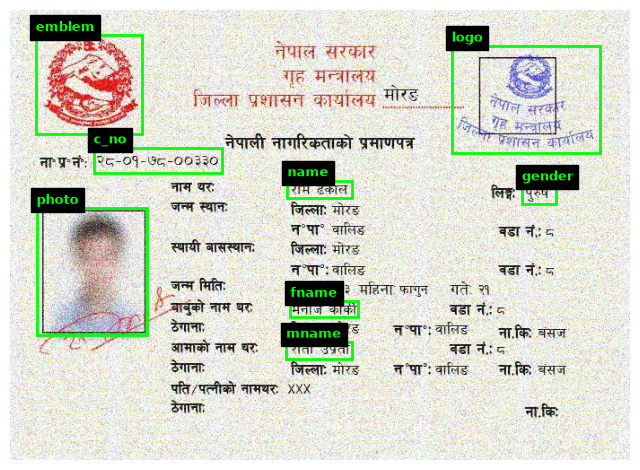


Data Set 10_front-nagarikta_aug2_phone_tilt_jpg.rf.N4qRkdDsmHY4LFo3vXTy.jpg:
  emblem
  logo
  photo
  fname
  mname
  c_no
  name
  gender


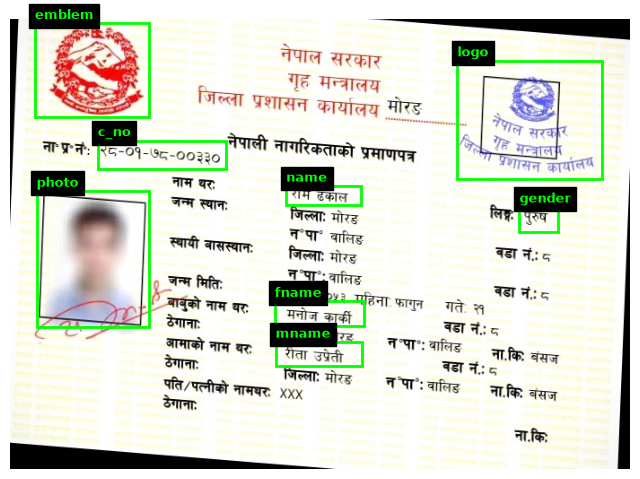

In [14]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image

class_names = ['c_no', 'emblem', 'fname', 'gender', 'logo', 'mname', 'name', 'photo']

def show_ground_truth(image_filename):
    img_path = os.path.join("train/images", image_filename)
    label_path = os.path.join("train/labels", image_filename.rsplit(".", 1)[0] + ".txt")

    img = Image.open(img_path)
    w, h = img.size

    fig, ax = plt.subplots(1, figsize=(8, 10))
    ax.imshow(img)

    print(f"\n{image_filename}:")
    with open(label_path) as f:
        for line in f:
            parts = line.strip().split()
            cls_id = int(parts[0])
            cx, cy, bw, bh = map(float, parts[1:])
            x1 = (cx - bw/2) * w
            y1 = (cy - bh/2) * h
            box_w = bw * w
            box_h = bh * h
            print(f"  {class_names[cls_id]}")
            rect = patches.Rectangle((x1, y1), box_w, box_h, linewidth=2, edgecolor='lime', facecolor='none')
            ax.add_patch(rect)
            ax.text(x1, max(y1 - 5, 0), class_names[cls_id], color='lime', fontsize=9, weight='bold', backgroundcolor='black')

    plt.axis('off')
    plt.show()

# Check 2 different images
sample_images = sorted(os.listdir("train/images"))[:2]
for img_name in sample_images:
    show_ground_truth(img_name)

In [15]:
import re
import shutil
import random

random.seed(42)
VAL_RATIO = 0.2

SRC_IMAGES = "train/images"
SRC_LABELS = "train/labels"
DST_TRAIN_IMAGES = "train_split/images"
DST_TRAIN_LABELS = "train_split/labels"
DST_VAL_IMAGES = "valid/images"
DST_VAL_LABELS = "valid/labels"

def get_group_id(filename):
    # Updated: matches "Data Set 10" (space-separated) instead of "Data-Set-10"
    match = re.match(r"(Data Set \d+)_", filename)
    return match.group(1) if match else filename

all_images = [f for f in os.listdir(SRC_IMAGES) if f.lower().endswith((".jpg", ".jpeg", ".png"))]
print(f"Found {len(all_images)} images")

groups = {}
for fname in all_images:
    gid = get_group_id(fname)
    groups.setdefault(gid, []).append(fname)

print(f"Grouped into {len(groups)} unique source images")
sample_group = list(groups.items())[0]
print(f"Sample group '{sample_group[0]}':", sample_group[1])

Found 80 images
Grouped into 20 unique source images
Sample group 'Data Set 10': ['Data Set 10_front-nagarikta_aug1_noisy_jpg.rf.8mmJraJ1AO0KiUmopj1K.jpg', 'Data Set 10_front-nagarikta_aug2_phone_tilt_jpg.rf.N4qRkdDsmHY4LFo3vXTy.jpg', 'Data Set 10_front-nagarikta_aug3_blur_jpg.rf.i69VsS8dpi4lbhgwvcs3.jpg', 'Data Set 10_front-nagarikta_jpg.rf.4FHffz8PLCKuUKw6nXde.jpg']


In [16]:
group_ids = list(groups.keys())
random.shuffle(group_ids)

n_val_groups = max(1, round(len(group_ids) * VAL_RATIO))
val_groups = set(group_ids[:n_val_groups])
train_groups = set(group_ids[n_val_groups:])

print(f"Total groups: {len(group_ids)}")
print(f"  -> {len(train_groups)} groups to TRAIN")
print(f"  -> {len(val_groups)} groups to VALID")
print(f"  -> VALID groups: {sorted(val_groups)}")

for d in [DST_TRAIN_IMAGES, DST_TRAIN_LABELS, DST_VAL_IMAGES, DST_VAL_LABELS]:
    os.makedirs(d, exist_ok=True)

train_count = 0
val_count = 0
missing_labels = []

for gid, files in groups.items():
    target_img_dir = DST_VAL_IMAGES if gid in val_groups else DST_TRAIN_IMAGES
    target_lbl_dir = DST_VAL_LABELS if gid in val_groups else DST_TRAIN_LABELS

    for fname in files:
        label_name = os.path.splitext(fname)[0] + ".txt"
        src_img_path = os.path.join(SRC_IMAGES, fname)
        src_lbl_path = os.path.join(SRC_LABELS, label_name)

        if not os.path.exists(src_lbl_path):
            missing_labels.append(fname)
            continue

        shutil.copy2(src_img_path, os.path.join(target_img_dir, fname))
        shutil.copy2(src_lbl_path, os.path.join(target_lbl_dir, label_name))

        if gid in val_groups:
            val_count += 1
        else:
            train_count += 1

print(f"\nCopied {train_count} images to {DST_TRAIN_IMAGES}")
print(f"Copied {val_count} images to {DST_VAL_IMAGES}")

if missing_labels:
    print(f"\nWARNING: {len(missing_labels)} images had no label:")
    for f in missing_labels:
        print("  -", f)
else:
    print("\nNo missing labels — all good.")

Total groups: 20
  -> 16 groups to TRAIN
  -> 4 groups to VALID
  -> VALID groups: ['Data Set 14', 'Data Set 15', 'Data Set 2', 'Data Set 9']

Copied 64 images to train_split/images
Copied 16 images to valid/images

No missing labels — all good.


In [17]:
if os.path.exists("train_original"):
    shutil.rmtree("train_original")
os.rename("train", "train_original")
os.rename("train_split", "train")

print("Done.")
print("train/images:", len(os.listdir("train/images")))
print("train/labels:", len(os.listdir("train/labels")))
print("valid/images:", len(os.listdir("valid/images")))
print("valid/labels:", len(os.listdir("valid/labels")))

Done.
train/images: 64
train/labels: 64
valid/images: 36
valid/labels: 36


In [18]:
yaml_content = """train: train/images
val: valid/images

nc: 8
names: ['c_no', 'emblem', 'fname', 'gender', 'logo', 'mname', 'name', 'photo']
"""

with open("data.yaml", "w") as f:
    f.write(yaml_content)

print(open("data.yaml").read())

train: train/images
val: valid/images

nc: 8
names: ['c_no', 'emblem', 'fname', 'gender', 'logo', 'mname', 'name', 'photo']



In [26]:
from ultralytics import YOLO

model = YOLO("yolov8n.pt")

results = model.train(
    data="data.yaml",
    epochs=100,
    imgsz=640,
    batch=16,
    name="doc_field_detector_v3",
    patience=20,
    device=0
)

New https://pypi.org/project/ultralytics/8.4.126 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.115  Python-3.11.9 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 4060 Laptop GPU, 8188MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=tr

e:\Sign_Train_First\myenv\Lib\site-packages\ultralytics\utils\tal.py:401: UserWarning: cumsum_cuda_kernel does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\builder\windows\pytorch\aten\src\ATen\Context.cpp:95.)
  sx = feats[0].new_ones(w, dtype=dtype).cumsum(0) - (1 - grid_cell_offset)  # shift x
e:\Sign_Train_First\myenv\Lib\site-packages\ultralytics\utils\tal.py:402: UserWarning: cumsum_cuda_kernel does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\buil

AMP: checks passed 
WARNING train: Slow image access detected (ping: 0.10.0 ms, read: 5.81.2 MB/s, size: 118.2 KB). Use local storage instead of remote/mounted storage for better performance. See https://docs.ultralytics.com/guides/model-training-tips/
train: Scanning C:\Users\Lenovo\Desktop\KYC_Project\train\labels... 80 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 80/80 524.5it/s 0.2s0.2s
train: New cache created: C:\Users\Lenovo\Desktop\KYC_Project\train\labels.cache
WARNING val: Slow image access detected (ping: 0.10.0 ms, read: 22.718.9 MB/s, size: 117.8 KB). Use local storage instead of remote/mounted storage for better performance. See https://docs.ultralytics.com/guides/model-training-tips/
val: Scanning C:\Users\Lenovo\Desktop\KYC_Project\valid\labels... 20 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 20/20 666.7it/s 0.0s
val: New cache created: C:\Users\Lenovo\Desktop\KYC_Project\valid\labels.cache
optimizer: 'optimizer=auto' found, ignoring 'lr0=0.01' and 'mome

e:\Sign_Train_First\myenv\Lib\site-packages\ultralytics\utils\tal.py:401: UserWarning: cumsum_cuda_kernel does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\builder\windows\pytorch\aten\src\ATen\Context.cpp:95.)
  sx = feats[0].new_ones(w, dtype=dtype).cumsum(0) - (1 - grid_cell_offset)  # shift x
e:\Sign_Train_First\myenv\Lib\site-packages\ultralytics\utils\tal.py:402: UserWarning: cumsum_cuda_kernel does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\buil

      1/100      2.39G      2.045      4.165      1.682        197        640: 100% ━━━━━━━━━━━━ 5/5 3.5s/it 17.6s0.2s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 1/1 4.6it/s 0.2s
                   all         20        154     0.0145      0.375     0.0493     0.0236

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      2/100      2.39G      2.155      4.233      1.631        252        640: 0% ──────────── 0/5  0.1s

...

     71/100      2.42G     0.9336     0.6101     0.9769        236        640: 100% ━━━━━━━━━━━━ 5/5 8.7it/s 0.6s0.2s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 1/1 7.2it/s 0.1s
                   all         20        154      0.937      0.987      0.961      0.685

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     72/100      2.42G     0.9005     0.5912      1.012        185        640: 0% ──────────── 0/5  0.1s

e:\Sign_Train_First\myenv\Lib\site-packages\ultralytics\utils\tal.py:401: UserWarning: cumsum_cuda_kernel does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\builder\windows\pytorch\aten\src\ATen\Context.cpp:95.)
  sx = feats[0].new_ones(w, dtype=dtype).cumsum(0) - (1 - grid_cell_offset)  # shift x
e:\Sign_Train_First\myenv\Lib\site-packages\ultralytics\utils\tal.py:402: UserWarning: cumsum_cuda_kernel does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\buil

     72/100      2.42G     0.9105     0.6019     0.9802        207        640: 100% ━━━━━━━━━━━━ 5/5 9.1it/s 0.6s0.1s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 1/1 5.0it/s 0.2s
                   all         20        154      0.939      0.987      0.962      0.683

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     73/100      2.42G     0.9401     0.5908     0.9465        277        640: 0% ──────────── 0/5  0.1s

e:\Sign_Train_First\myenv\Lib\site-packages\ultralytics\utils\tal.py:401: UserWarning: cumsum_cuda_kernel does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\builder\windows\pytorch\aten\src\ATen\Context.cpp:95.)
  sx = feats[0].new_ones(w, dtype=dtype).cumsum(0) - (1 - grid_cell_offset)  # shift x
e:\Sign_Train_First\myenv\Lib\site-packages\ultralytics\utils\tal.py:402: UserWarning: cumsum_cuda_kernel does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\buil

     73/100      2.42G     0.9339     0.5955     0.9691        229        640: 100% ━━━━━━━━━━━━ 5/5 8.5it/s 0.6s0.2s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 1/1 7.3it/s 0.1s
                   all         20        154      0.938      0.987      0.959      0.692
EarlyStopping: Training stopped early as no improvement observed in last 20 epochs. Best results observed at epoch 53, best model saved as best.pt.
To update EarlyStopping(patience=20) pass a new patience value, i.e. `patience=300` or use `patience=0` to disable EarlyStopping.

73 epochs completed in 0.025 hours.
Optimizer stripped from C:\Users\Lenovo\Desktop\KYC_Project\runs\detect\doc_field_detector_v3\weights\last.pt, 6.2MB
Optimizer stripped from C:\Users\Lenovo\Desktop\KYC_Project\runs\detect\doc_field_detector_v3\weights\best.pt, 6.2MB

Validating C:\Users\Lenovo\Desktop\KYC_Project\runs\detect\doc_field_detector_v3\weights\best.pt...
Ultralytics 8.4.11

In [27]:
os.makedirs("ml/docservice/models", exist_ok=True)

shutil.copy2(
    "runs/detect/doc_field_detector_v3/weights/best.pt",
    "ml/docservice/models/doc_field_detector_v3.pt"
)

print("Saved to: ml/docservice/models/doc_field_detector_v3.pt")

Saved to: ml/docservice/models/doc_field_detector_v3.pt


In [19]:
from ultralytics import YOLO
from PIL import Image

doc_model = YOLO("ml/docservice/models/doc_field_detector_v3.pt")

def detect_and_crop(image_path, conf_threshold=0.5, save_crops=False, output_dir="cropped_fields"):
    results = doc_model.predict(source=image_path, conf=conf_threshold, verbose=False)
    original_image = Image.open(image_path).convert("RGB")
    detections = {}
    for box in results[0].boxes:
        cls_id = int(box.cls[0])
        cls_name = doc_model.names[cls_id]
        conf = float(box.conf[0])
        x1, y1, x2, y2 = map(int, box.xyxy[0].tolist())
        if cls_name in detections and detections[cls_name]["confidence"] >= conf:
            continue
        crop = original_image.crop((x1, y1, x2, y2))
        detections[cls_name] = {"crop": crop, "confidence": conf, "bbox": (x1, y1, x2, y2)}
    if save_crops:
        os.makedirs(output_dir, exist_ok=True)
        base_name = os.path.splitext(os.path.basename(image_path))[0]
        for cls_name, data in detections.items():
            save_path = os.path.join(output_dir, f"{base_name}_{cls_name}.jpg")
            data["crop"].save(save_path)
    return detections

test_image = os.path.join("valid/images", os.listdir("valid/images")[0])
fields = detect_and_crop(test_image, save_crops=True)

print(f"Detected {len(fields)} fields on {test_image}:\n")
for cls_name, data in fields.items():
    print(f"{cls_name}: confidence={data['confidence']:.2f}, bbox={data['bbox']}")

Detected 8 fields on valid/images\Data Set 14_front-nagarikta_aug1_noisy_jpg.rf.uqWgti2NqpVXPxUyfR46.jpg:

photo: confidence=0.93, bbox=(29, 219, 153, 362)
mname: confidence=0.93, bbox=(309, 367, 388, 389)
logo: confidence=0.92, bbox=(497, 31, 655, 163)
emblem: confidence=0.91, bbox=(29, 23, 150, 137)
c_no: confidence=0.85, bbox=(90, 155, 236, 181)
fname: confidence=0.84, bbox=(309, 322, 383, 344)
gender: confidence=0.78, bbox=(571, 193, 619, 216)
name: confidence=0.55, bbox=(305, 189, 371, 211)
